In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import os
import torch
import torch.nn as nn
from torch.autograd import Variable
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
import cv2
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import seaborn as sns

In [2]:
# List files in the input directory
print(os.listdir("../input"))

folder_names = os.listdir("/kaggle/input/aslamerican-sign-language-aplhabet-dataset/ASL_Alphabet_Dataset/asl_alphabet_train")
labels = []
data_images = []

for index, folder in enumerate(folder_names):
    image_files = os.listdir(f"/kaggle/input/aslamerican-sign-language-aplhabet-dataset/ASL_Alphabet_Dataset/asl_alphabet_train/{folder}/")
    for image_file in image_files:
        image_path = f"/kaggle/input/aslamerican-sign-language-aplhabet-dataset/ASL_Alphabet_Dataset/asl_alphabet_train/{folder}/{image_file}"
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        image = cv2.resize(image, (32, 32))
        image = image / 255.0
        data_images.append([image])
        labels.append(index)

data_images = np.array(data_images, dtype=np.float32)
labels = np.array(labels, dtype=np.float32)


['aslamerican-sign-language-aplhabet-dataset', 'gp-asl-img']


In [3]:
features_train, features_test, labels_train, labels_test = train_test_split(data_images, labels, test_size=0.2, random_state=42)
featuresTrain = torch.from_numpy(features_train)
labelsTrain = torch.from_numpy(labels_train).type(torch.LongTensor)
featuresTest = torch.from_numpy(features_test)
labelsTest = torch.from_numpy(labels_test).type(torch.LongTensor)


In [4]:
train = DataLoader(torch.utils.data.TensorDataset(featuresTrain, labelsTrain), batch_size=100, shuffle=False)
test = DataLoader(torch.utils.data.TensorDataset(featuresTest, labelsTest), batch_size=100, shuffle=False)


In [5]:
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.cnn1 = nn.Conv2d(1, 16, 5, 1, 0)
        self.relu1 = nn.ReLU()
        self.maxpool1 = nn.MaxPool2d(2)
        self.cnn2 = nn.Conv2d(16, 32, 5, 1, 0)
        self.relu2 = nn.ReLU()
        self.maxpool2 = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(32 * 5 * 5, 29)

    def forward(self, x):
        x = self.maxpool1(self.relu1(self.cnn1(x)))
        x = self.maxpool2(self.relu2(self.cnn2(x)))
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        return x

model = CNNModel()
error = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)


In [7]:
num_epochs = 20  # Adjust this according to your training needs

for epoch in range(num_epochs):
    # Training
    model.train()
    total_train = 0
    correct_train = 0
    train_loss = 0

    for images, labels in train:
        batch_size = images.size(0)  # Get current batch size dynamically
        images = Variable(images.view(batch_size, 1, 32, 32))
        labels = Variable(labels)
        optimizer.zero_grad()
        outputs = model(images)
        loss = error(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_accuracy = 100 * correct_train / total_train
    avg_train_loss = train_loss / len(train)

    # Validation
    model.eval()
    total_val = 0
    correct_val = 0
    val_loss = 0

    with torch.no_grad():
        for images, labels in test:
            batch_size = images.size(0)  # Get current batch size dynamically
            images = Variable(images.view(batch_size, 1, 32, 32))
            labels = Variable(labels)
            outputs = model(images)
            loss = error(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_accuracy = 100 * correct_val / total_val
    avg_val_loss = val_loss / len(test)

    # Print training and validation results
    print(f'Epoch {epoch + 1}, Loss: {avg_train_loss:.4f}, Accuracy: {train_accuracy:.2f}%, Val Loss: {avg_val_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%')


Epoch 1, Loss: 0.9924, Accuracy: 71.47%, Val Loss: 0.8897, Val Accuracy: 74.10%
Epoch 2, Loss: 0.6473, Accuracy: 81.72%, Val Loss: 0.6172, Val Accuracy: 82.90%
Epoch 3, Loss: 0.4878, Accuracy: 86.47%, Val Loss: 0.4915, Val Accuracy: 86.74%
Epoch 4, Loss: 0.3939, Accuracy: 89.25%, Val Loss: 0.4226, Val Accuracy: 88.85%
Epoch 5, Loss: 0.3329, Accuracy: 91.00%, Val Loss: 0.3946, Val Accuracy: 89.52%
Epoch 6, Loss: 0.2913, Accuracy: 92.18%, Val Loss: 0.3934, Val Accuracy: 89.33%
Epoch 7, Loss: 0.2616, Accuracy: 92.98%, Val Loss: 0.3517, Val Accuracy: 91.04%
Epoch 8, Loss: 0.2375, Accuracy: 93.55%, Val Loss: 0.3272, Val Accuracy: 91.82%
Epoch 9, Loss: 0.2177, Accuracy: 94.07%, Val Loss: 0.3089, Val Accuracy: 92.34%
Epoch 10, Loss: 0.2002, Accuracy: 94.56%, Val Loss: 0.3144, Val Accuracy: 92.05%
Epoch 11, Loss: 0.1870, Accuracy: 94.95%, Val Loss: 0.2906, Val Accuracy: 92.76%
Epoch 12, Loss: 0.1767, Accuracy: 95.20%, Val Loss: 0.2870, Val Accuracy: 92.91%
Epoch 13, Loss: 0.1660, Accuracy: 95.

In [16]:
torch.save(model.state_dict(), 'asl_cnn_model.pth')
print("Model saved successfully!")


Model saved successfully!


In [13]:
predicted_labels = []
true_labels = []
for images, labels in test:
    # Use images.size(0) to dynamically get the batch size
    batch_size = images.size(0)
    images = images.view(batch_size, 1, 32, 32)
    outputs = model(images)
    predicted = torch.max(outputs.data, 1)[1]
    predicted_labels.extend(predicted.cpu().numpy())  # Assuming use of GPU
    true_labels.extend(labels.cpu().numpy())  # Assuming use of GPU


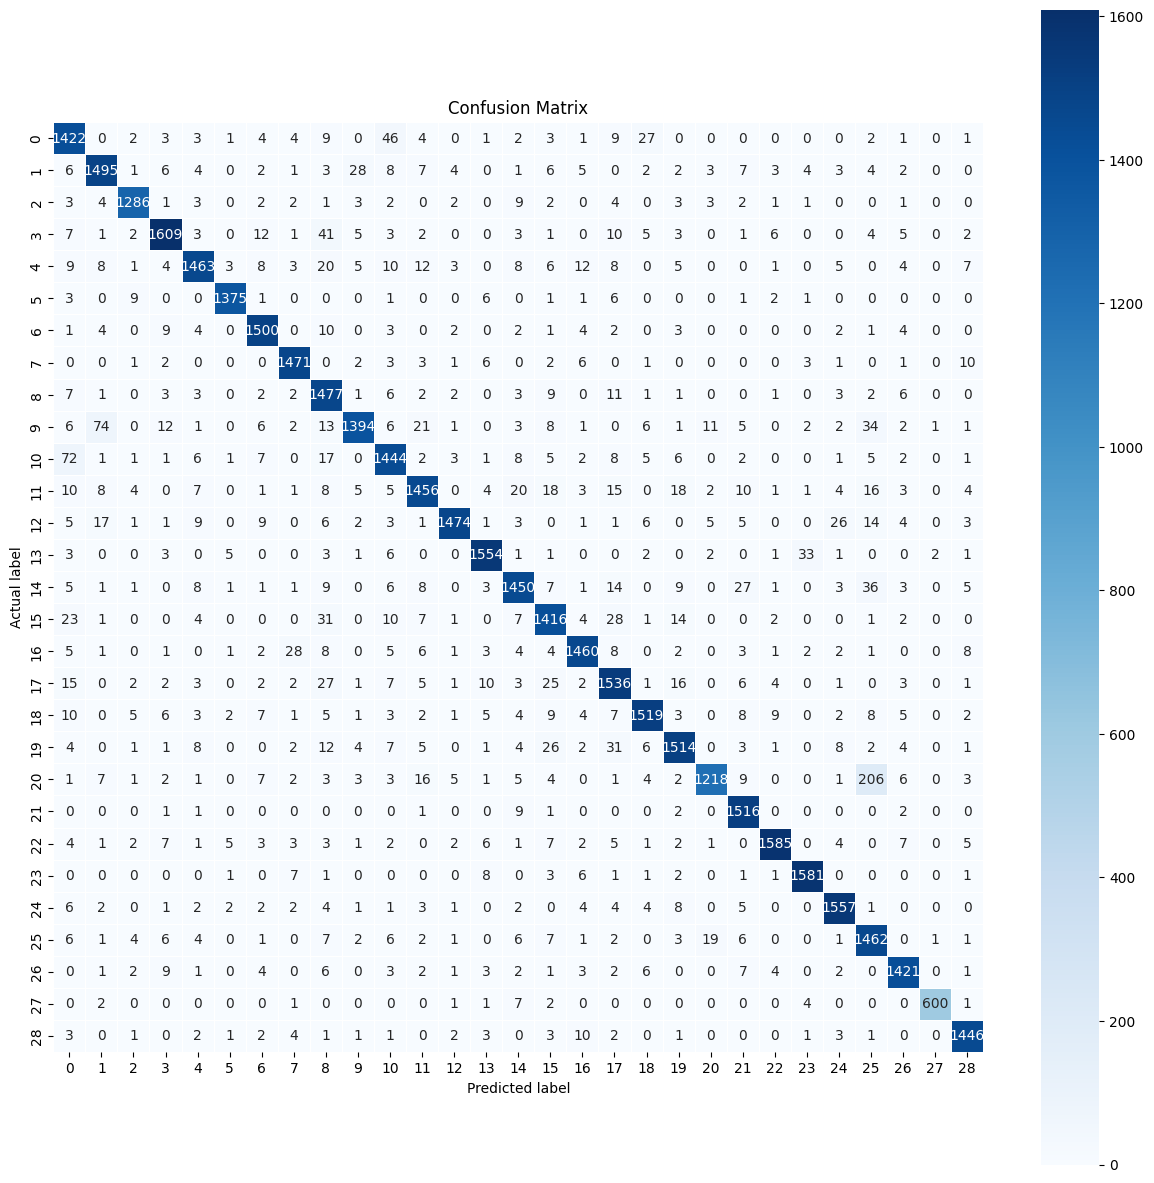

In [15]:
cm = confusion_matrix(true_labels, predicted_labels)
plt.figure(figsize=(15, 15))
sns.heatmap(cm, annot=True, fmt='d', linewidths=.5, square=True, cmap='Blues')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.title('Confusion Matrix')
plt.show()